# Loan Default Prediction for Credit Risk Assessment

## EXECUTIVE SUMMARY 
In today’s banking system, managing loan risk is very important to keep the bank financially strong and profitable. When a bank gives loans, there is always a chance that some customers may not repay them. Recently, XYZ Bank has seen a rise in such cases, with around 18% of loans not being repaid. This has caused financial losses and increased risk for the bank.

Right now, the bank uses a basic rule-based system to decide whether to approve a loan or not. This system only looks at simple conditions and does not fully understand how different factors like a customer’s income, existing debts, and past credit behavior are connected. Because of this, the bank may sometimes make wrong decisions while approving loans.

This project aims to build a data-driven machine learning solution using the Lending Club Loan Data (2007–2014). The goal is to move from a simple rule-based system to a more intelligent prediction system that can better assess loan risk.

#### Key Objectives:
- To predict the probability of a customer defaulting on a loan
- To identify the key factors that influence loan default, such as income, debt, and credit history
- To segment customers into different risk categories (low, medium, and high risk)
- To recommend an improved and optimized loan approval strategy based on risk levels

#### Business Impact 
##### Reduce default rates
- Help the bank give loans only to the right customers, so fewer people fail to repay<br>
##### Improve profitability
- By reducing bad loans, the bank can save money and earn more profit<br>
##### Enable smarter lending decisions
- Help the bank make better and more accurate decisions instead of relying on basic rules

## PROBLEM DEFINITION
#### Business Problem
XYZ Bank is currently facing a few major challenges:
- The number of customers not repaying their loans is increasing
- The current system is not good at identifying risky customers
- Because of this, the bank is losing money due to bad loans
#### Analytical Problem
From a data perspective, this problem can be understood as a yes or no prediction:
- 1->Customer will not repay the loan (Default)
- 0 ->Customer will repay the loan (Non-default)<br>
So, the task is to predict whether a customer will default or not based on their information.
#### Goal
The main goal of this project is to build a machine learning model that helps the bank make better loan approval decisions by identifying risky customers in advance.


## Dataset Description
The dataset contains historical loan data including borrower characteristics, financial metrics, and loan performance.
#### Key Features:
- Loan Amount
- Interest Rate
- Annual Income
- Debt-to-Income Ratio (DTI)
- Credit Grade
#### Target variable:
loan_status
- Fully Paid → 0
- Charged Off → 1

## Data Preprocessing & Feature Engineering

In [1]:
# Import libraries
# !pip install xgboost imbalanced-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [2]:
# Load dataset
df = pd.read_csv("loan_data_2007_2014.csv", low_memory=False)
df.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

Unnamed: 0               0
id                       0
member_id                0
loan_amnt                0
funded_amnt              0
                     ...  
all_util            466285
total_rev_hi_lim     70276
inq_fi              466285
total_cu_tl         466285
inq_last_12m        466285
Length: 75, dtype: int64

## Target Variable Creation

In [4]:
df = df[df['loan_status'].isin(['Fully Paid','Charged Off'])]
df['target'] = df['loan_status'].map({'Fully Paid':0,'Charged Off':1})

## Missing Value Handling
Columns with excessive missing values (>50%) are removed. Remaining missing values are imputed using statistical techniques.

In [5]:
# Remove columns with too many missing values
missing = df.isnull().mean() * 100
df = df.drop(columns=missing[missing > 50].index)

# Separate columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill missing values
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna("Unknown")

## Feature Engineering
To enhance model performance, new features are created:

In [6]:
df['income_to_loan'] = df['annual_inc']/(df['loan_amnt']+1)
df['risk_score'] = df['int_rate']*df['dti']
df['loan_intensity'] = df['loan_amnt']/df['annual_inc']

In [7]:
# Encoding 
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str)  # ensure string
    df[col] = le.fit_transform(df[col])

# Drop unwanted columns safely
X = df.drop(columns=['target', 'loan_status'], errors='ignore')
y = df['target']

#  Remove any remaining NaN / inf 
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

## Exploratory Data Analysis (EDA)

### Univariate 

#### Target Distribution

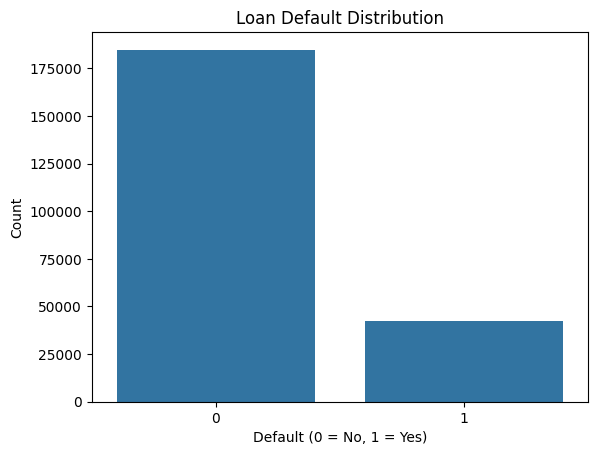

In [8]:
sns.countplot(x=y)
plt.title("Loan Default Distribution")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

The dataset is imbalanced, with significantly more non-default cases than default cases. 
This imbalance justifies the use of techniques like SMOTE to improve model performance.

#### Loan Amount Distribution

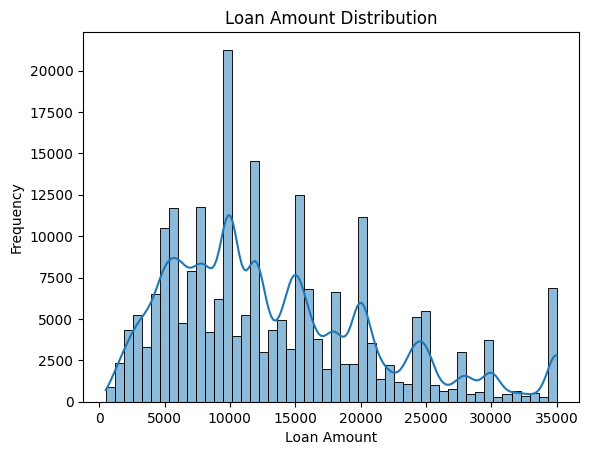

In [9]:
sns.histplot(df['loan_amnt'], bins=50, kde=True)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

Most loans are concentrated in the lower range, with fewer high-value loans. 
This indicates that the bank primarily issues small to medium-sized loans.

#### Interest Rate Distribution

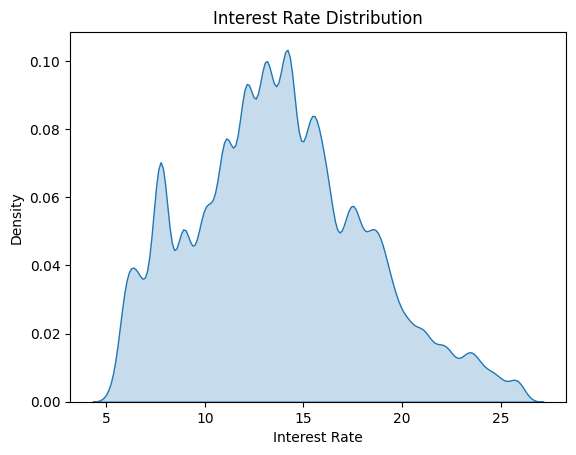

In [10]:
sns.kdeplot(df['int_rate'], fill=True)
plt.title("Interest Rate Distribution")
plt.xlabel("Interest Rate")
plt.ylabel("Density")
plt.show()

Interest rates are distributed across a wide range, indicating varying levels of borrower risk. 
Higher interest rates typically correspond to riskier customers.

#### Income Distribution

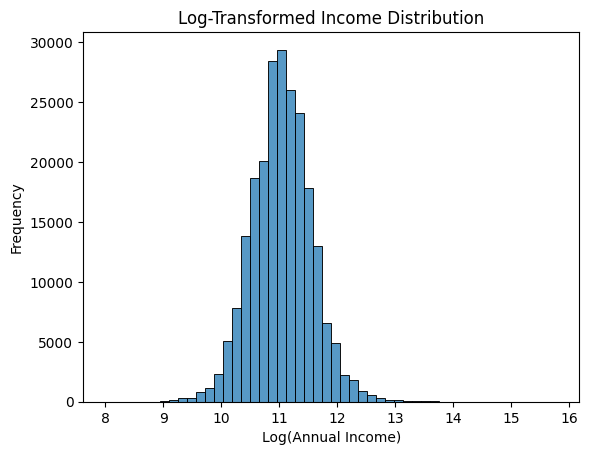

In [11]:
sns.histplot(np.log1p(df['annual_inc']), bins=50)
plt.title("Log-Transformed Income Distribution")
plt.xlabel("Log(Annual Income)")
plt.ylabel("Frequency")
plt.show()

Income distribution is right-skewed, so a log transformation is applied to normalize the data. 
This helps improve model performance and interpretability.

### Bivariate 

#### Interest Rate vs Default

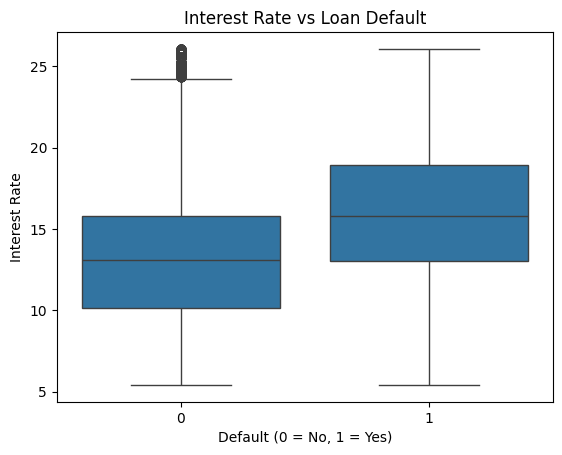

In [12]:
sns.boxplot(x='target', y='int_rate', data=df)
plt.title("Interest Rate vs Loan Default")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Interest Rate")
plt.show()

Customers with higher interest rates show a higher likelihood of default. 
This suggests that interest rate is a strong indicator of borrower risk.

#### DTI vs Default

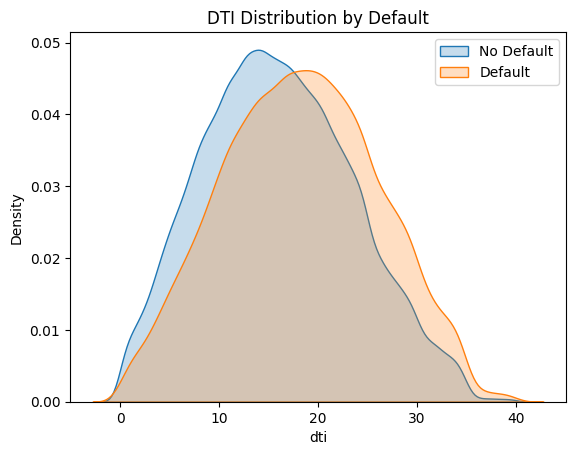

In [13]:
sns.kdeplot(data=df[df['target']==0]['dti'], label='No Default', fill=True)
sns.kdeplot(data=df[df['target']==1]['dti'], label='Default', fill=True)

plt.title("DTI Distribution by Default")
plt.legend()
plt.show()

Customers with higher debt-to-income ratios are more likely to default. 
This indicates that financial burden plays a key role in loan repayment ability.

#### Grade vs Default

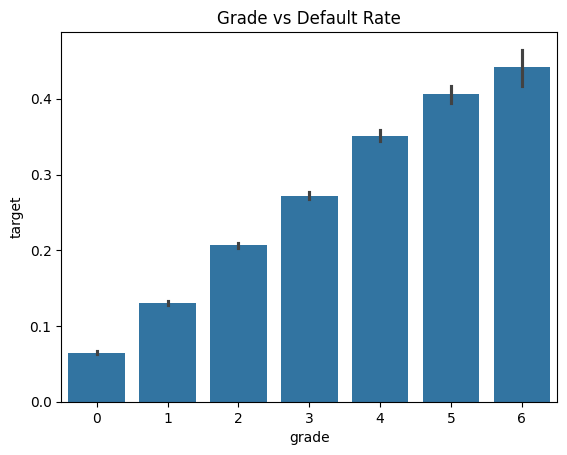

In [14]:
sns.barplot(x='grade', y='target', data=df)
plt.title("Grade vs Default Rate")
plt.show()

Lower credit grades are associated with higher default rates. 
This shows that credit grading is an effective risk segmentation tool.

### Removing Data Leakage Features
Certain columns such as total payment, recoveries, and last payment amount contain information that is available only after the loan is issued. Including these features would lead to data leakage, as the model would indirectly know the outcome of the loan.<br>
To ensure a realistic and reliable prediction model, these columns were removed so that only information available at the time of loan approval is used.

In [15]:
drop_cols = [
    'loan_status',
    'total_pymnt','total_pymnt_inv',
    'last_pymnt_amnt','last_pymnt_d',
    'recoveries','collection_recovery_fee',
    'total_rec_prncp','total_rec_int','total_rec_late_fee',
    'out_prncp','out_prncp_inv',
    'last_credit_pull_d'
]

df = df.drop(columns=drop_cols, errors='ignore')

In [16]:
df = df.sample(20000, random_state=42) # Sampling data to reduce computation time

In [17]:
X = df.drop(['target'], axis=1)
y = df['target']

## Correlation Heatmap

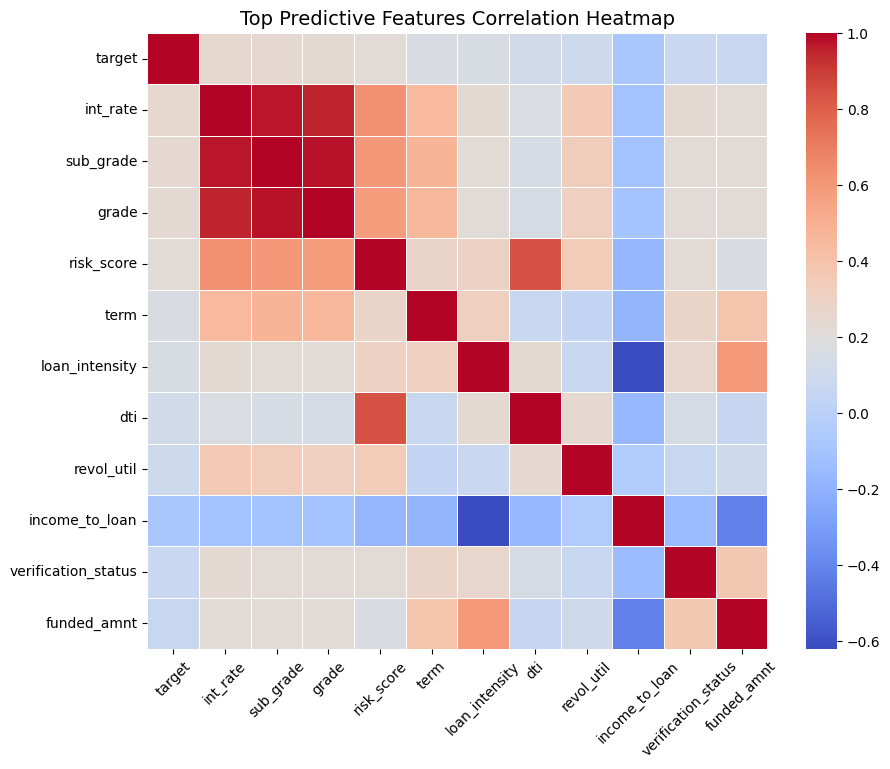

In [18]:
corr = df.corr()['target'].abs().sort_values(ascending=False)
top_features = corr.index[:12]
plt.figure(figsize=(10,8))
sns.heatmap(df[top_features].corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Top Predictive Features Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

Features such as interest rate, credit grade, DTI, and engineered features like risk_score show strong relationships with the target variable. 
These are key predictors of loan default.

#### Risk Score vs Default

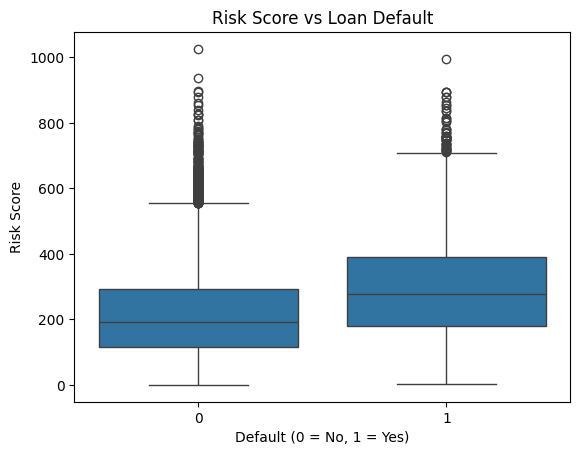

In [19]:
sns.boxplot(x='target', y='risk_score', data=df)
plt.title("Risk Score vs Loan Default")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Risk Score")
plt.show()

Higher risk scores are associated with higher default probability. 
This validates the effectiveness of the engineered risk_score feature.

#### Income-to-Loan Ratio

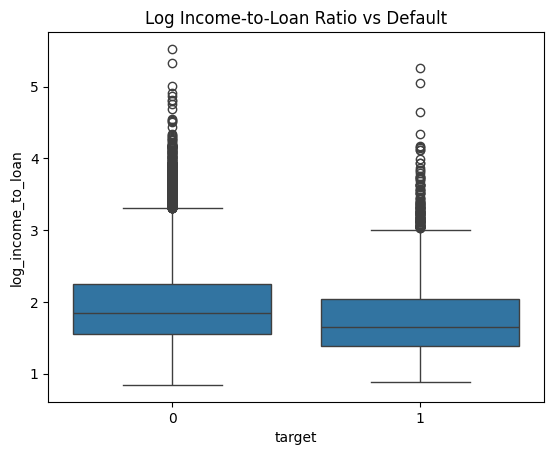

In [20]:
df['log_income_to_loan'] = np.log1p(df['income_to_loan'])
sns.boxplot(x='target', y='log_income_to_loan', data=df)
plt.title("Log Income-to-Loan Ratio vs Default")
plt.show() 

Lower income-to-loan ratios are linked to higher default rates, indicating that customers with lower repayment capacity are more risky.

## MODEL BUILDING 

### Model Building & Advanced Evaluation
This section builds multiple machine learning models, compares their performance, and selects the best model for deployment.

### Models Used
We implement multiple models to compare performance:
- Logistic Regression (baseline)
- Decision Tree
- Random Forest
-  GradientBoosting

In [21]:
#Split
X = df.drop(columns=['target'], errors='ignore')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
#scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#smote 
from imblearn.over_sampling import SMOTE # Apply SMOTE to handle class imbalance

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, solver='liblinear'),
    "Decision Tree": DecisionTreeClassifier(max_depth=6),
    "Random Forest": RandomForestClassifier(n_estimators=50),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

### Model Training & Evaluation
Each model is trained and evaluated using:
- Accuracy
- Precision
- Recall
- ROC-AUC

In [22]:
results = []

for name, model in models.items():
    try:
        model.fit(X_train_res, y_train_res)
        
        pred = model.predict(X_test)
        
        # Safe probability handling
        if hasattr(model, "predict_proba"):
            prob = model.predict_proba(X_test)[:,1]
        elif hasattr(model, "decision_function"):
            prob = model.decision_function(X_test)
        else:
            prob = pred
        
        acc = accuracy_score(y_test, pred)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        auc = roc_auc_score(y_test, prob)
        
        results.append([name, acc, prec, rec, auc])
    
    except Exception as e:
        print(f"Error in model {name}: {e}")

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","ROC-AUC"])

results_df

,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,0.65275,0.299937,0.624011,0.694988
1,Decision Tree,0.72125,0.307858,0.377309,0.655067
2,Random Forest,0.79275,0.398860,0.184697,0.668581
3,Gradient Boosting,0.77875,0.378585,0.261214,0.680667
4,XGBoost,0.79625,0.398577,0.147757,0.671172


### Confusion matrix

In [23]:
from sklearn.metrics import confusion_matrix

rf = models["Random Forest"]   # already trained
pred = rf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))

Confusion Matrix:
[[3031  211]
 [ 618  140]]


### Model Comparison Visualization

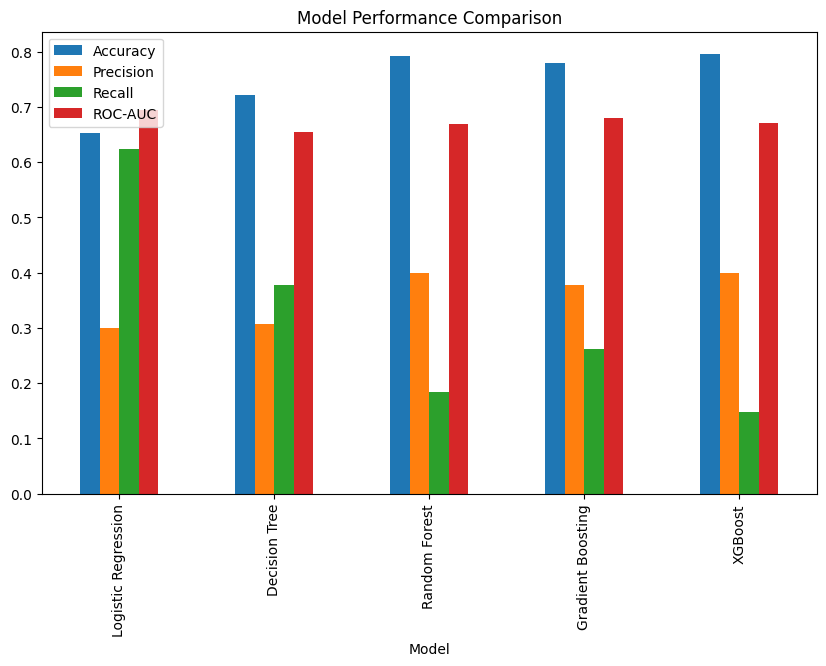

In [24]:
results_df.set_index("Model").plot(kind='bar', figsize=(10,6))
plt.title("Model Performance Comparison")
plt.show()

### Hyperparameter Tuning

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[50,100],
    'max_depth':[5,8]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)

grid.fit(X_train_res, y_train_res)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

best_rf = grid.best_estimator_

Best Parameters: {'max_depth': 8, 'n_estimators': 50}
Best Score: 0.7798982188295165


### ROC Curve Comparison

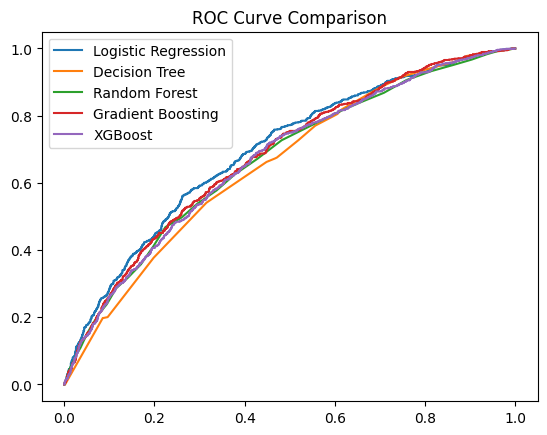

In [26]:
from sklearn.metrics import roc_curve
plt.figure()
for name, model in models.items():
    prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

The ROC curve compares the performance of different models in distinguishing between default and non-default customers. It can be observed that all models perform reasonably well, with ensemble models like Random Forest, Gradient Boosting, and XGBoost showing slightly better performance. This indicates that these models are more effective in identifying high-risk customers.


### Feature Importance

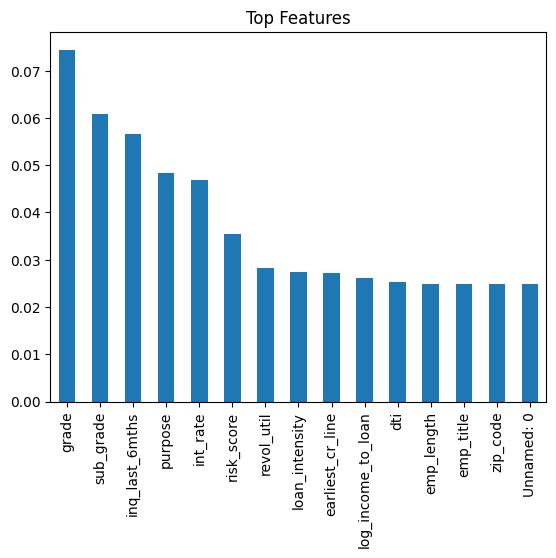

In [27]:
rf = models["Random Forest"]

feat_imp = pd.Series(rf.feature_importances_, index=X.columns)

feat_imp.sort_values(ascending=False).head(15).plot(kind='bar')

plt.title("Top Features")
plt.show()

### Threshold Optimization

In [28]:
from sklearn.metrics import precision_score, recall_score
probs = best_rf.predict_proba(X_test)[:,1]
for t in [0.3,0.4,0.5,0.6]:
    preds = (probs > t).astype(int)
    print(t,
          "Recall:", recall_score(y_test, preds),
          "Precision:", precision_score(y_test, preds))

0.3 Recall: 0.8535620052770448 Precision: 0.2355296687295231
0.4 Recall: 0.6820580474934037 Precision: 0.27397986221515636
0.5 Recall: 0.47229551451187335 Precision: 0.32604735883424407
0.6 Recall: 0.2546174142480211 Precision: 0.3784313725490196


### BUSINESS SIMULATION

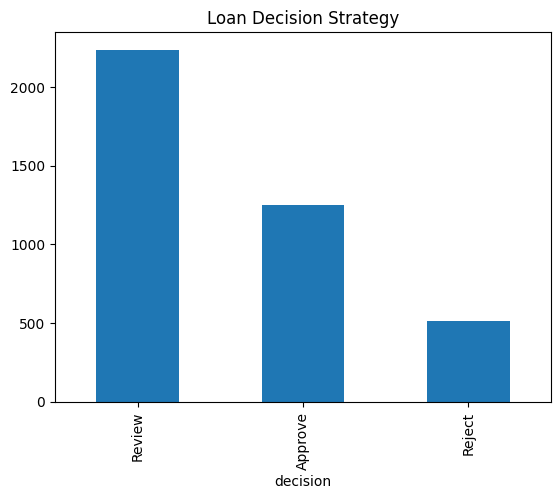

In [29]:
df_sim = pd.DataFrame({'prob':probs})

df_sim['decision'] = df_sim['prob'].apply(
    lambda x: "Reject" if x>0.6 else "Review" if x>0.3 else "Approve"
)

df_sim['decision'].value_counts().plot(kind='bar')
plt.title("Loan Decision Strategy")
plt.show()

## Insights
Higher interest rates are strongly associated with increased default probability, indicating that riskier borrowers are more likely to default.
- Customers with higher interest rates are more likely to default on their loans
High DTI = high financial stress
- Customers who have a high debt-to-income ratio are under more financial pressure and are more likely to miss payments
Feature engineering improved model performance
- Creating new features like risk score and income-to-loan ratio helped the model make better and more accurate predictions
ML models outperform rule-based system
-  Machine learning models perform better than the bank’s existing rule-based system because they can understand complex patterns in the data

## BUSINESS RECOMMENDATIONS

1. Smart Approval Strategy
- Approve low-risk applicants  
- Review medium-risk applicants  
- Reject high-risk applicants  

2. Risk-Based Pricing
- Charge higher interest rates for high-risk borrowers  
- Offer lower rates for low-risk customers  

3. Monitoring System
- Track borrowers continuously to detect early signs of default  

4. Deployment
- Integrate the model into the loan approval process  

In [30]:
df.to_csv("cleaned_data.csv", index=False)

## FINAL CONCLUSION

This project successfully builds a credit risk prediction system that helps:

- Improve decision-making  
- Reduce loan defaults  
- Increase overall profitability  

The model can support banks in making smarter and data-driven lending decisions.